# National Electricity Load Forecasting System
### Research and Modeling Pipeline

Methodology: **Build -> Validate -> Improve**

---

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 2. Data Loading and Trustworthiness Check

In [2]:
df = pd.read_csv('Egypt_Governorates_Load_Dataset_Advanced.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.sort_values(['Governorate', 'Datetime'], inplace=True)

print(f'Total Records: {len(df):,}')
print('Missing Values:')
print(df.isnull().sum())
df.head()

Total Records: 140,112
Missing Values:
Datetime                 0
Governorate              0
Temperature_C            0
Humidity_Percent         0
Hour                     0
Month                    0
Day_of_Year              0
Day_of_Week              0
Is_Weekend               0
Season                   0
CDH                      0
Temp_x_Hour              0
CDH_x_Is_Weekend         0
Lag_1h                   0
Lag_24h                  0
Lag_168h                 0
Electricity_Demand_MW    0
dtype: int64


,Datetime,Governorate,Temperature_C,Humidity_Percent,Hour,Month,Day_of_Year,Day_of_Week,Is_Weekend,Season,CDH,Temp_x_Hour,CDH_x_Is_Weekend,Lag_1h,Lag_24h,Lag_168h,Electricity_Demand_MW
20016,2024-01-08 00:00:00,Alexandria,14.5,58,0,1,8,0,0,Winter,0.0,0.0,0.0,2420.9,2479.4,2416.0,2425.5
20017,2024-01-08 01:00:00,Alexandria,14.3,64,1,1,8,0,0,Winter,0.0,14.3,0.0,2425.5,2487.3,2430.2,2453.1
20018,2024-01-08 02:00:00,Alexandria,13.9,71,2,1,8,0,0,Winter,0.0,27.8,0.0,2453.1,2275.6,2283.2,2242.3
20019,2024-01-08 03:00:00,Alexandria,14.1,80,3,1,8,0,0,Winter,0.0,42.3,0.0,2242.3,2264.4,2269.3,2225.7
20020,2024-01-08 04:00:00,Alexandria,13.9,84,4,1,8,0,0,Winter,0.0,55.6,0.0,2225.7,2277.3,2270.2,2230.3


## 3. Narrative EDA (Exploratory Data Analysis)

We analyze outliers, distribution skewness, and feature correlations with scientific interpretation.

Outliers Detected: 20024 (14.29%)
Load Skewness: 2.1497


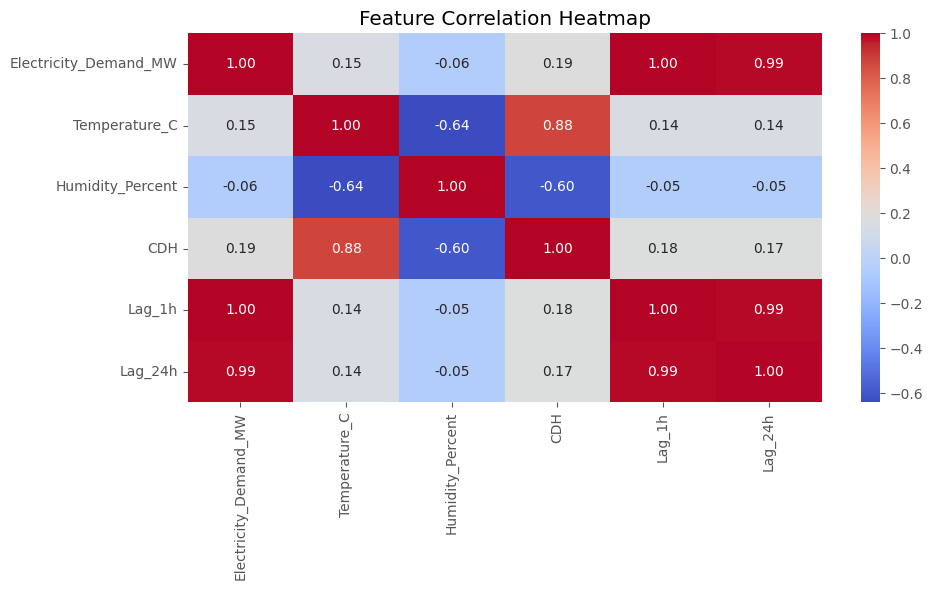

In [ ]:
# 3.1 Outlier Detection using IQR
Q1 = df['Electricity_Demand_MW'].quantile(0.25)
Q3 = df['Electricity_Demand_MW'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Electricity_Demand_MW'] < lower) | (df['Electricity_Demand_MW'] > upper)]
print(f'Outliers Detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

# 3.2 Skewness
skew = df['Electricity_Demand_MW'].skew()
print(f'Load Skewness: {skew:.4f}') 

# 3.3 Correlation Heatmap
plt.figure(figsize=(10, 6))
num_cols = ['Electricity_Demand_MW', 'Temperature_C', 'Humidity_Percent', 'CDH', 'Lag_1h', 'Lag_24h']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

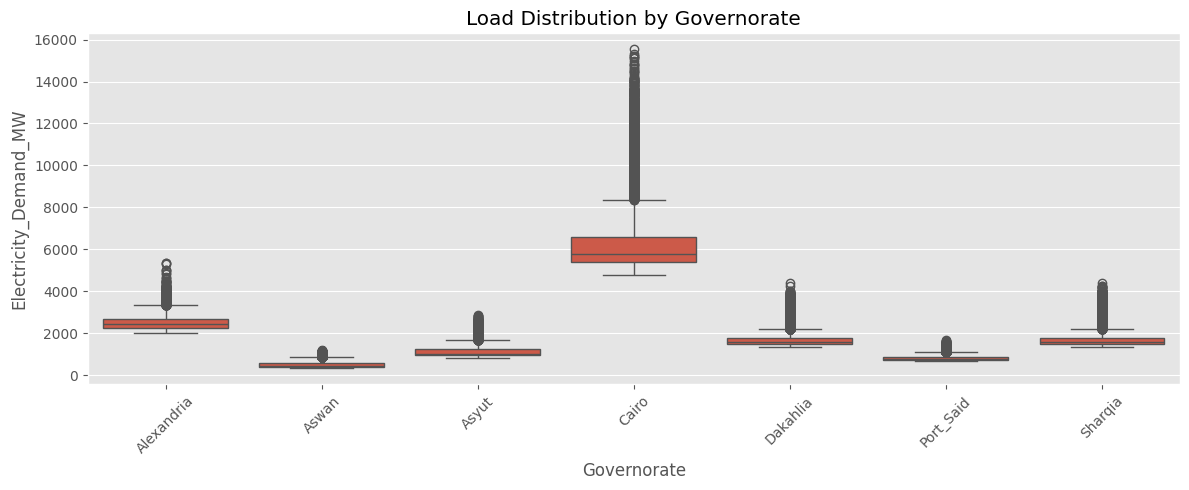

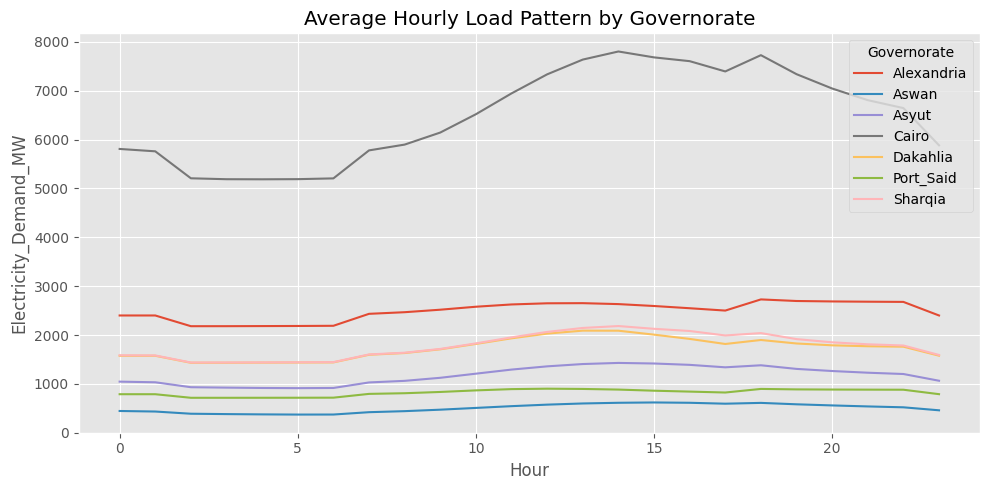

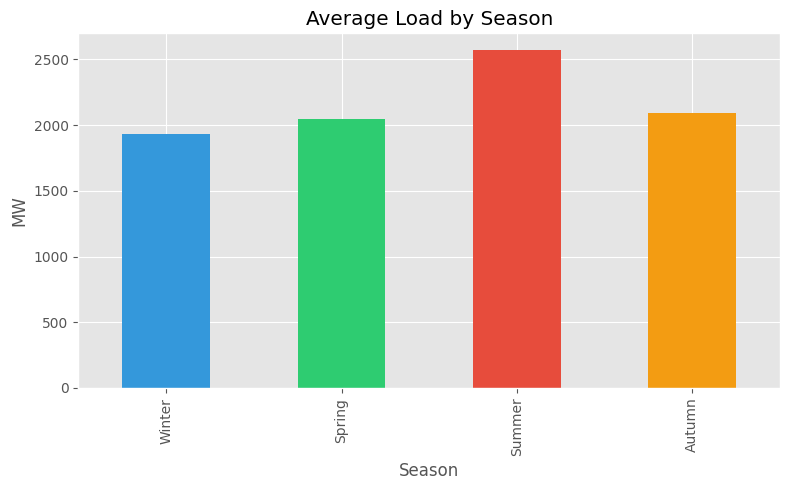

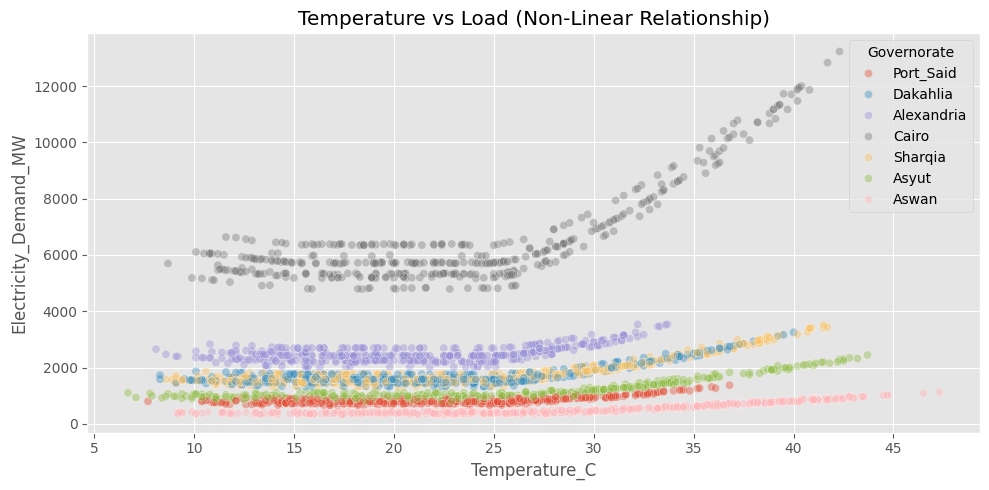

In [4]:
# 3.4 Load Distribution per Governorate
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Governorate', y='Electricity_Demand_MW')
plt.title('Load Distribution by Governorate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.5 Hourly Load Pattern
plt.figure(figsize=(10, 5))
hourly = df.groupby(['Hour', 'Governorate'])['Electricity_Demand_MW'].mean().reset_index()
sns.lineplot(data=hourly, x='Hour', y='Electricity_Demand_MW', hue='Governorate')
plt.title('Average Hourly Load Pattern by Governorate')
plt.tight_layout()
plt.show()

# 3.6 Seasonal Pattern
plt.figure(figsize=(8, 5))
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal = df.groupby('Season')['Electricity_Demand_MW'].mean().reindex(season_order)
seasonal.plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Average Load by Season')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

# 3.7 Temperature vs Load (Non-linear relationship)
plt.figure(figsize=(10, 5))
sample = df.sample(3000, random_state=42)
sns.scatterplot(data=sample, x='Temperature_C', y='Electricity_Demand_MW', hue='Governorate', alpha=0.4)
plt.title('Temperature vs Load (Non-Linear Relationship)')
plt.tight_layout()
plt.show()

## 4. Data Splitting (Time-Based)

We use chronological splitting (not random) to prevent data leakage in time-series forecasting.

In [ ]:
split_idx = int(len(df) * 0.8)        # 80 % ==> Train
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

features = ['Governorate', 'Temperature_C', 'Humidity_Percent', 'Hour', 'Month',
            'Day_of_Week', 'Is_Weekend', 'Season', 'CDH', 'Temp_x_Hour',
            'Lag_1h', 'Lag_24h']
target = 'Electricity_Demand_MW'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

print(f'Train: {len(train):,} rows ({train["Datetime"].min()} to {train["Datetime"].max()})')
print(f'Test:  {len(test):,} rows ({test["Datetime"].min()} to {test["Datetime"].max()})')

Train: 112,089 rows (2024-01-08 00:00:00 to 2026-04-20 23:00:00)
Test:  28,023 rows (2024-01-08 00:00:00 to 2026-04-20 23:00:00)


## 5. Model Competition (LR vs RF vs XGBoost)

Same preprocessor, same split, same features. Only the model changes.

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

results = []
pipelines = {}
predictions = {}

for name, model in models.items():
    print(f'Training {name}...')
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    
    preds = pipe.predict(X_test)
    predictions[name] = preds
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)})

comparison_df = pd.DataFrame(results).sort_values('MAE')
print('\n--- Model Comparison ---')
print(comparison_df.to_string(index=False))

Training Linear Regression...
Training Random Forest...
Training XGBoost...

--- Model Comparison ---
            Model   MAE  RMSE     R2
    Random Forest 25.11 58.96 0.9897
          XGBoost 31.67 50.59 0.9924
Linear Regression 52.00 79.63 0.9813


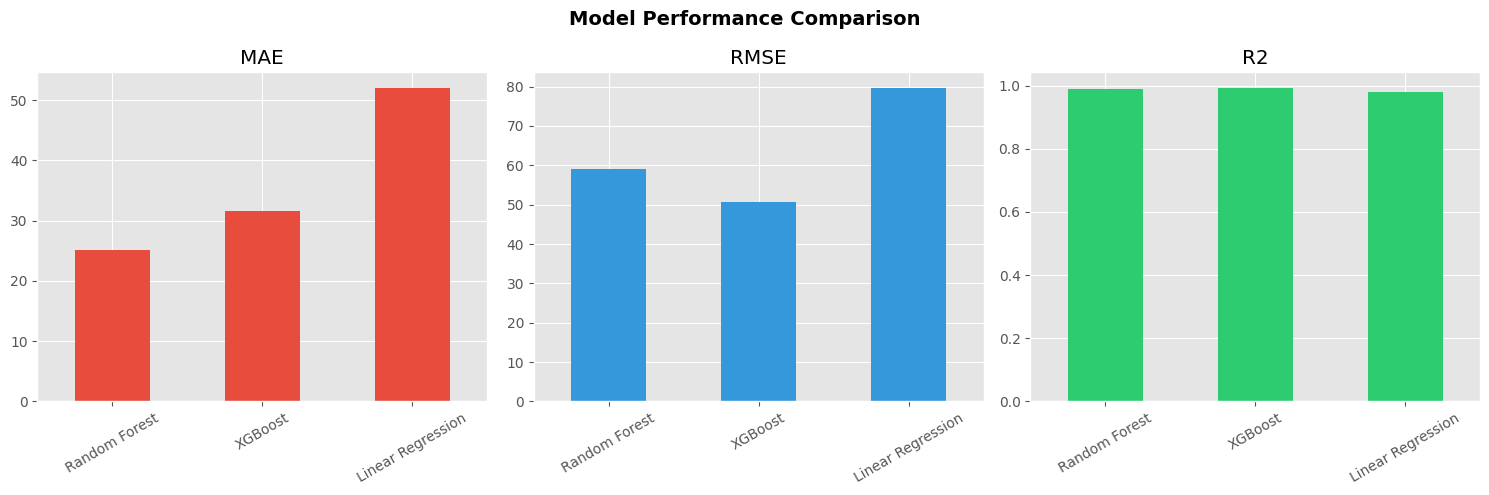

In [ ]:
# Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#e74c3c', '#3498db', "#2ecc38"]

for ax, metric, color in zip(axes, metrics, colors):
    comparison_df.plot.bar(x='Model', y=metric, ax=ax, color=color, legend=False)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Advanced Evaluation

Error analysis by hour and season for the best model.

Best Model: Random Forest


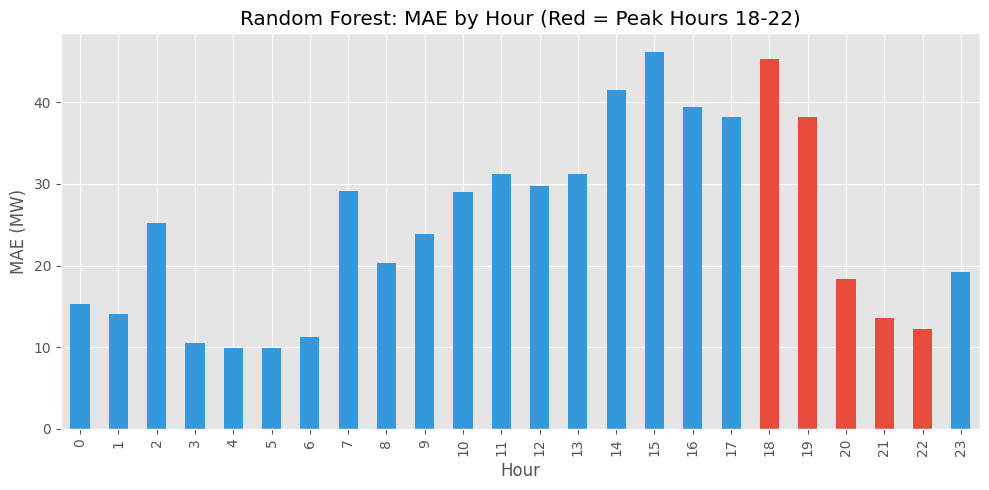

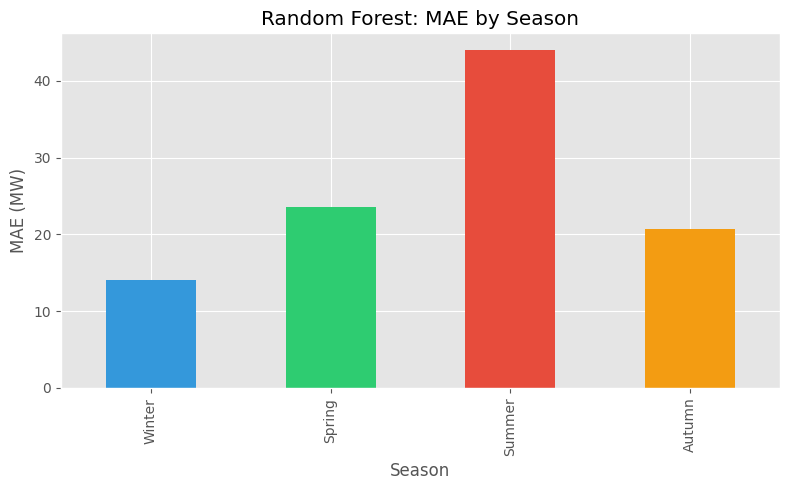

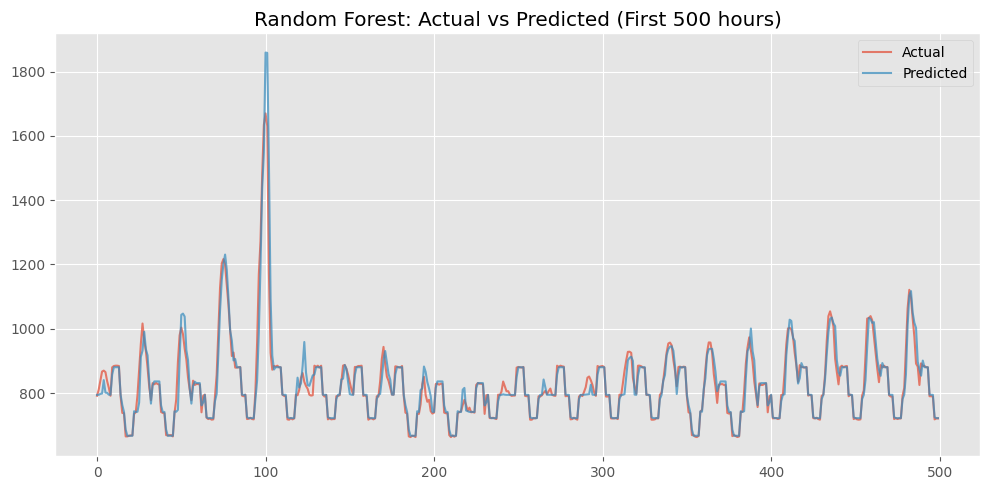

Peak Hours (18-22) MAE:    25.51 MW
Off-Peak Hours MAE:        25.01 MW


In [ ]:
best_name = comparison_df.iloc[0]['Model']
best_preds = predictions[best_name]
print(f'Best Model: {best_name}')

eval_df = test[['Hour', 'Season']].copy()
eval_df['Error'] = np.abs(y_test.values - best_preds)

# 6.1 Error by Hour
plt.figure(figsize=(10, 5))
hourly_err = eval_df.groupby('Hour')['Error'].mean()
hourly_err.plot(kind='bar', color=['#e74c3c' if h in range(18,23) else '#3498db' for h in range(24)])
plt.title(f'{best_name}: MAE by Hour (Red = Peak Hours 18-22)')
plt.ylabel('MAE (MW)')
plt.tight_layout()
plt.show()

# 6.2 Error by Season
plt.figure(figsize=(8, 5))
season_err = eval_df.groupby('Season')['Error'].mean().reindex(['Winter','Spring','Summer','Autumn'])
season_err.plot(kind='bar', color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
plt.title(f'{best_name}: MAE by Season')
plt.ylabel('MAE (MW)')
plt.tight_layout()
plt.show()

# 6.3 Actual vs Predicted
plt.figure(figsize=(10, 5))
sample_idx = range(0, min(500, len(y_test)))
plt.plot(y_test.values[sample_idx], label='Actual', alpha=0.7)
plt.plot(best_preds[sample_idx], label='Predicted', alpha=0.7)
plt.title(f'{best_name}: Actual vs Predicted (First 500 hours)')
plt.legend()
plt.tight_layout()
plt.show()

# 6.4 Peak vs Off-Peak MAE
peak_mask = eval_df['Hour'].between(18, 22)
peak_mae = eval_df.loc[peak_mask, 'Error'].mean()
offpeak_mae = eval_df.loc[~peak_mask, 'Error'].mean()
print(f'Peak Hours (18-22) MAE:    {peak_mae:.2f} MW')
print(f'Off-Peak Hours MAE:        {offpeak_mae:.2f} MW')

## 7. Feature Importance (XGBoost)

Understanding which features drive the predictions.

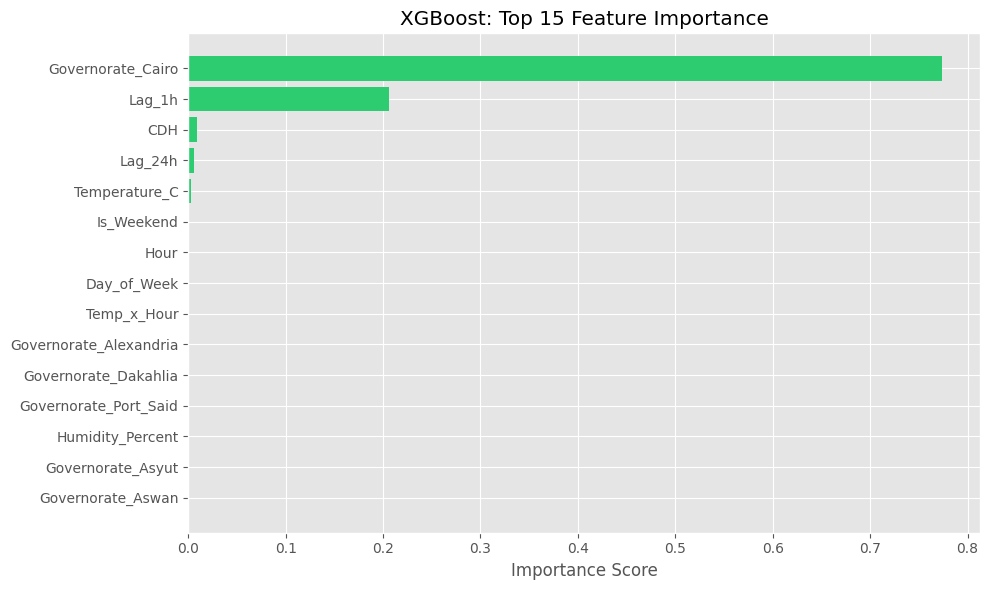

In [ ]:
if 'XGBoost' in pipelines:
    xgb_pipe = pipelines['XGBoost']
    xgb_model = xgb_pipe.named_steps['model']
    
    # Get feature names after preprocessing
    prep = xgb_pipe.named_steps['prep']
    cat_names = list(prep.named_transformers_['cat'].get_feature_names_out(categorical_cols))
    all_feature_names = numeric_cols + cat_names
    
    importances = xgb_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=True).tail(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2ecc71')
    plt.title('XGBoost: Top 15 Feature Importance')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

## 8. Export Best Model

In [ ]:
best_pipe = pipelines[best_name]
residuals = y_test.values - best_preds
conf_margin = 1.96 * np.std(residuals)

joblib.dump({
    'pipeline': best_pipe,
    'feature_order': features,
    'confidence_margin': conf_margin,
    'comparison_results': results,
    'best_model': best_name
}, 'model_pipeline.pkl')

print(f'Best Model: {best_name}')
print(f'Confidence Margin: +/- {conf_margin:.2f} MW')
print('Pipeline saved to model_pipeline.pkl')

Best Model: Random Forest
Confidence Margin: +/- 115.53 MW
Pipeline saved to model_pipeline.pkl
